# 09 — Comparação de Achados: HDBSCAN Original vs LOF

**Objetivo:** Comparar e cruzar os dois conjuntos de municípios excepcionais identificados por abordagens distintas:
- **HDBSCAN (NB05/NB06):** 204 municípios em sub-clusters densos (apenas C0 e C3)
- **LOF (NB07):** 559 municípios com score de anomalia alto (todos os clusters)

**Perguntas a responder:**
1. Os 204 municípios do HDBSCAN têm LOF score alto? (validação cruzada)
2. Quais municípios aparecem nos dois métodos? (núcleo de excepcionalidade)
3. O que o LOF encontrou que o HDBSCAN ignorou?
4. O sub-cluster do Agronegócio MT/MS (C3, Sub-3001) é confirmado pelo LOF?
5. Qual abordagem identifica municípios mais regulatoriamente relevantes?

**Entrada:** `rqual_2022_clusterizado_v2.parquet`  
**Saída:** `comparacao_achados_hdbscan_lof.csv`, figuras de comparação

In [1]:
# Bloco 0 — Setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display

ARQ = Path('rqual_2022_clusterizado_v2.parquet')

CORES_CLUSTERS = ['#1976D2', '#388E3C', '#F57C00', '#D32F2F', '#7B1FA2']
CLUSTER_NOMES  = {
    0: 'C0: Urbano-Avançado',
    1: 'C1: Intermediário',
    2: 'C2: Nordeste Periférico',
    3: 'C3: Norte/Amazônico',
    4: 'C4: Capitais/Destaques',
}
NOMES_CURTOS = {
    0: 'Urbano-Avançado',
    1: 'Intermediário',
    2: 'Nordeste Periférico',
    3: 'Norte/Amazônico',
    4: 'Capitais/Destaques',
}
print('Setup concluído.')

Setup concluído.


In [2]:
# Bloco 1 — Carregar base enriquecida (saída do NB07)
df = pd.read_parquet(ARQ)
print(f'Shape: {df.shape}')

# Renomear colunas longas se necessário
rename_map = {}
for col in df.columns:
    cl = col.lower()
    if 'agropecuária' in cl or 'agropecuaria' in cl:   rename_map[col] = 'pib_agropecuaria'
    elif 'indústria' in cl or 'industria' in cl:        rename_map[col] = 'pib_industria'
    elif 'per capita' in cl:                             rename_map[col] = 'pib_per_capita'
    elif 'área' in cl or ('area' in cl and 'km' in cl): rename_map[col] = 'area_km2'
    elif 'densidade' in cl:                              rename_map[col] = 'densidade'
    elif 'rural' in cl and 'urb' in cl:                  rename_map[col] = 'pop_rural'
    elif col.startswith('IDHM') and '__' in col:         rename_map[col] = 'idhm'
    elif col.startswith('LAT__lat'):                     rename_map[col] = 'lat'
    elif col.startswith('LAT__lon'):                     rename_map[col] = 'lon'
df = df.rename(columns=rename_map)

IND_COLS = [c for c in ['IND2','IND4','IND5','IND8','IND9','INF1','INF4-UP'] if c in df.columns]
SOC_COLS = [c for c in ['pib_agropecuaria','pib_industria','pib_per_capita',
                         'area_km2','densidade','pop_rural','idhm'] if c in df.columns]

# Criar flags de pertencimento para facilitar análise
df['flag_hdbscan'] = ~df['hdbscan_noise']        # True = estava em sub-cluster HDBSCAN
df['flag_lof']     = df['lof_outlier'].astype(bool)  # True = identificado como excepcional pelo LOF

print(f'\nTotal municípios: {len(df):,}')
print(f'Identificados pelo HDBSCAN: {df["flag_hdbscan"].sum():,} ({100*df["flag_hdbscan"].mean():.1f}%)')
print(f'Identificados pelo LOF:     {df["flag_lof"].sum():,} ({100*df["flag_lof"].mean():.1f}%)')

Shape: (5570, 32)

Total municípios: 5,570
Identificados pelo HDBSCAN: 204 (3.7%)
Identificados pelo LOF:     559 (10.0%)


---
## Seção 1 — Sobreposição entre HDBSCAN e LOF

Classificamos cada município em uma das quatro categorias:

| Categoria | HDBSCAN | LOF | Interpretação |
|---|:---:|:---:|---|
| **Núcleo convergente** | ✓ | ✓ | Ambos os métodos concordam: município genuinamente excepcional |
| **Só HDBSCAN** | ✓ | ✗ | Sub-grupo denso, mas não isolado no seu cluster — padrão coeso |
| **Só LOF** | ✗ | ✓ | Município isolado sem grupo denso ao redor — anomalia pontual |
| **Consenso normal** | ✗ | ✗ | Município típico do seu cluster |

In [3]:
# Bloco 2 — Análise de sobreposição
df['categoria'] = 'Consenso normal'
df.loc[ df['flag_hdbscan'] &  df['flag_lof'], 'categoria'] = 'Núcleo convergente'
df.loc[ df['flag_hdbscan'] & ~df['flag_lof'], 'categoria'] = 'Só HDBSCAN'
df.loc[~df['flag_hdbscan'] &  df['flag_lof'], 'categoria'] = 'Só LOF'

contagem = df['categoria'].value_counts()
print('=' * 55)
print('SOBREPOSIÇÃO HDBSCAN × LOF')
print('=' * 55)
for cat, n in contagem.items():
    print(f'  {cat:<25} : {n:5,} ({100*n/len(df):.1f}%)')

n_convergente = contagem.get('Núcleo convergente', 0)
n_so_hdb = contagem.get('Só HDBSCAN', 0)
n_so_lof = contagem.get('Só LOF', 0)

print()
if n_convergente > 0:
    prec_hdb = 100 * n_convergente / df['flag_hdbscan'].sum()
    prec_lof = 100 * n_convergente / df['flag_lof'].sum()
    print(f'  % do HDBSCAN confirmado pelo LOF : {prec_hdb:.1f}%')
    print(f'  % do LOF confirmado pelo HDBSCAN : {prec_lof:.1f}%')

print()
print('Distribuição por cluster:')
cross = pd.crosstab(df['kmeans_cluster'].map(NOMES_CURTOS), df['categoria'])
display(cross)

SOBREPOSIÇÃO HDBSCAN × LOF
  Consenso normal           : 4,807 (86.3%)
  Só LOF                    :   559 (10.0%)
  Só HDBSCAN                :   204 (3.7%)


Distribuição por cluster:


categoria,Consenso normal,Só HDBSCAN,Só LOF
kmeans_cluster,,,
Capitais/Destaques,24,0,3
Intermediário,2748,0,306
Nordeste Periférico,1851,0,206
Norte/Amazônico,63,131,22
Urbano-Avançado,121,73,22


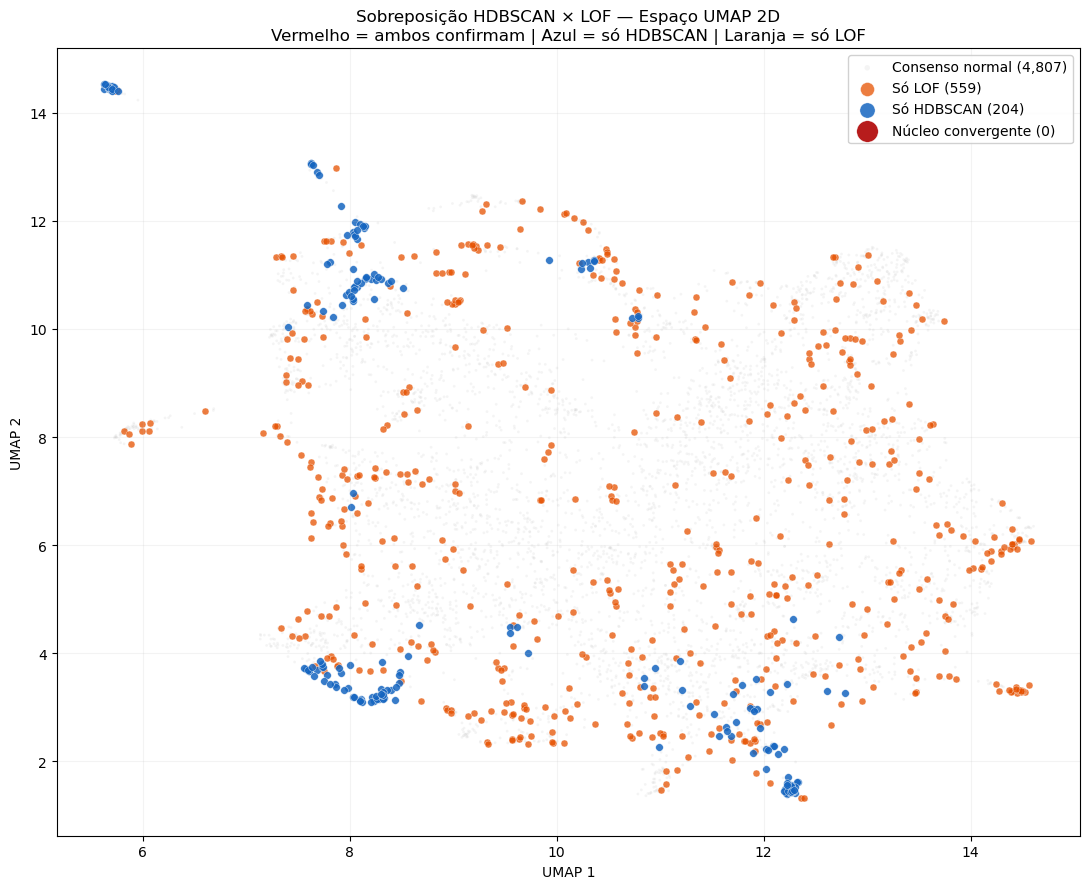

Salvo: fig_sobreposicao_hdbscan_lof.png


In [4]:
# Bloco 3 — Visualização da sobreposição no espaço UMAP
CORES_CAT = {
    'Núcleo convergente': '#B71C1C',   # vermelho escuro — excepcional confirmado
    'Só HDBSCAN':         '#1565C0',   # azul — sub-grupo denso
    'Só LOF':             '#E65100',   # laranja — anomalia pontual
    'Consenso normal':    '#CCCCCC',   # cinza — típico
}
TAMANHOS_CAT = {
    'Consenso normal': 4,
    'Só LOF': 25,
    'Só HDBSCAN': 30,
    'Núcleo convergente': 60,
}
ALFA_CAT = {
    'Consenso normal': 0.2,
    'Só LOF': 0.75,
    'Só HDBSCAN': 0.85,
    'Núcleo convergente': 1.0,
}
ORDEM = ['Consenso normal', 'Só LOF', 'Só HDBSCAN', 'Núcleo convergente']

fig, ax = plt.subplots(figsize=(11, 9))

for cat in ORDEM:
    sub = df[df['categoria'] == cat]
    n   = len(sub)
    ax.scatter(
        sub['umap_x'], sub['umap_y'],
        c=CORES_CAT[cat],
        s=TAMANHOS_CAT[cat],
        alpha=ALFA_CAT[cat],
        linewidths=0.3 if cat != 'Consenso normal' else 0,
        edgecolors='white' if cat != 'Consenso normal' else 'none',
        label=f'{cat} ({n:,})'
    )

ax.set_title('Sobreposição HDBSCAN × LOF — Espaço UMAP 2D\n'
             'Vermelho = ambos confirmam | Azul = só HDBSCAN | Laranja = só LOF',
             fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10, markerscale=2, framealpha=0.9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig('fig_sobreposicao_hdbscan_lof.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_sobreposicao_hdbscan_lof.png')

---
## Seção 2 — Validação Cruzada: LOF score dos municípios HDBSCAN

Se o HDBSCAN e o LOF capturam a mesma sinal de excepcionalidade, esperamos que os municípios
identificados pelo HDBSCAN tenham **LOF score sistematicamente maior** que os demais.

LOF SCORE: municípios HDBSCAN vs demais
  HDBSCAN (n=204) | Mediana LOF: 1.005 | Média: 1.018
  Demais  (n=5,366) | Mediana LOF: 1.082 | Média: 1.118

  Teste Mann-Whitney U: stat=216252, p=1.0000
  → Resultado não significativo: LOF score similar entre grupos

  Percentil médio dos municípios HDBSCAN no ranking LOF: 20.9%
  (100% = todos no topo do ranking LOF; 50% = distribuição aleatória)


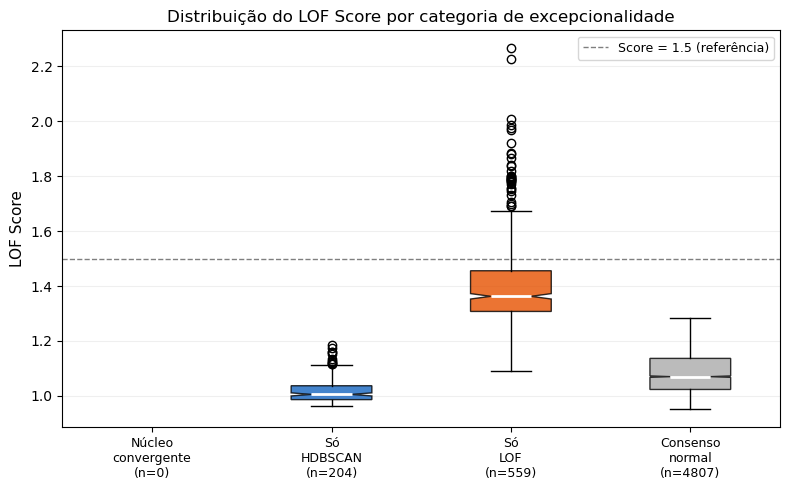

Salvo: fig_lof_score_por_categoria.png


In [5]:
# Bloco 4 — Distribuição do LOF score: municípios HDBSCAN vs demais
from scipy import stats

scores_hdb  = df.loc[df['flag_hdbscan'], 'lof_score']
scores_rest = df.loc[~df['flag_hdbscan'], 'lof_score']

# Teste estatístico: Mann-Whitney U (não paramétrico)
stat, p_val = stats.mannwhitneyu(scores_hdb, scores_rest, alternative='greater')

print('=' * 55)
print('LOF SCORE: municípios HDBSCAN vs demais')
print('=' * 55)
print(f'  HDBSCAN (n={len(scores_hdb):,}) | Mediana LOF: {scores_hdb.median():.3f} | Média: {scores_hdb.mean():.3f}')
print(f'  Demais  (n={len(scores_rest):,}) | Mediana LOF: {scores_rest.median():.3f} | Média: {scores_rest.mean():.3f}')
print()
print(f'  Teste Mann-Whitney U: stat={stat:.0f}, p={p_val:.4f}')
if p_val < 0.05:
    print('  → Resultado significativo (p < 0.05): municípios HDBSCAN têm LOF score maior ✓')
else:
    print('  → Resultado não significativo: LOF score similar entre grupos')

# Percentil do LOF score dos municípios HDBSCAN dentro da base
pct_lof_hdb = (scores_hdb.values[:, None] > df['lof_score'].values[None, :]).mean(axis=1).mean() * 100
print(f'\n  Percentil médio dos municípios HDBSCAN no ranking LOF: {pct_lof_hdb:.1f}%')
print(f'  (100% = todos no topo do ranking LOF; 50% = distribuição aleatória)')

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [
    df.loc[df['flag_hdbscan'] & df['flag_lof'], 'lof_score'],
    df.loc[df['flag_hdbscan'] & ~df['flag_lof'], 'lof_score'],
    df.loc[~df['flag_hdbscan'] & df['flag_lof'], 'lof_score'],
    df.loc[~df['flag_hdbscan'] & ~df['flag_lof'], 'lof_score'],
]
labels_plot = [
    f'Núcleo\nconvergente\n(n={len(data_plot[0])})',
    f'Só\nHDBSCAN\n(n={len(data_plot[1])})',
    f'Só\nLOF\n(n={len(data_plot[2])})',
    f'Consenso\nnormal\n(n={len(data_plot[3])})',
]
cores_box = ['#B71C1C', '#1565C0', '#E65100', '#AAAAAA']

bp = ax.boxplot(data_plot, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)

ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylabel('LOF Score', fontsize=11)
ax.set_title('Distribuição do LOF Score por categoria de excepcionalidade', fontsize=12)
ax.axhline(1.5, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Score = 1.5 (referência)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('fig_lof_score_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_lof_score_por_categoria.png')

---
## Seção 3 — Achado-chave: Sub-cluster Agronegócio MT/MS confirmado pelo LOF?

O HDBSCAN identificou 19 municípios do Mato Grosso e Mato Grosso do Sul (Sub-3001) como uma **exceção positiva** dentro do C3 Norte/Amazônico:  
municípios remotos e rurais com qualidade de telecom muito acima do esperado para o seu contexto geográfico.  

O LOF deveria confirmar esses municípios com **score alto** (são atípicos dentro do C3) — mas a direção da exceção é positiva (melhor que o cluster), enquanto o LOF mede apenas a magnitude da anomalia, não a direção.

In [6]:
# Bloco 5 — Sub-cluster Agronegócio MT/MS: HDBSCAN vs LOF
c3 = df[df['kmeans_cluster'] == 3].copy()

# Sub-3001 = Agronegócio MT/MS (label 3001 do HDBSCAN original)
agro = c3[c3['hdbscan_cluster'] == 3001].copy()
amazonia = c3[c3['hdbscan_cluster'] == 3000].copy()
ruido_c3 = c3[c3['hdbscan_noise']].copy()

print('Sub-cluster Agronegócio MT/MS (Sub-3001) — perfil LOF:')
print(f'  N municípios: {len(agro)}')
print(f'  LOF score mediana : {agro["lof_score"].median():.3f}')
print(f'  LOF score máximo  : {agro["lof_score"].max():.3f}')
print(f'  Marcados como outlier LOF: {agro["flag_lof"].sum()} de {len(agro)}')
print()

# Comparar perfil médio por indicador RQUAL
grupos = {
    'Média Nacional':              df[IND_COLS].mean(),
    'C3 — Ruído HDBSCAN':         ruido_c3[IND_COLS].mean(),
    'C3 — Sub-0 Amazônia profunda': amazonia[IND_COLS].mean(),
    'C3 — Sub-1 Agronegócio MT/MS': agro[IND_COLS].mean(),
}
perfil_c3 = pd.DataFrame(grupos).T.round(3)
print('Perfil médio (z-scores):')
display(perfil_c3)

# Lista completa do sub-cluster com LOF scores
print('\nMunicípios do Sub-3001 com LOF score:')
display(
    agro[['nome_mun_rqual','uf_rqual','lof_score','flag_lof'] + IND_COLS[:4]]
    .sort_values('lof_score', ascending=False)
    .reset_index(drop=True)
    .round(3)
)

Sub-cluster Agronegócio MT/MS (Sub-3001) — perfil LOF:
  N municípios: 19
  LOF score mediana : 1.028
  LOF score máximo  : 1.174
  Marcados como outlier LOF: 0 de 19

Perfil médio (z-scores):


,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
Média Nacional,-0.016,0.010,-0.000,0.023,-0.000,0.000,-0.013
C3 — Ruído HDBSCAN,0.208,-1.772,-2.281,-1.231,-0.295,0.426,-0.197
C3 — Sub-0 Amazônia profunda,0.251,-1.808,-2.192,-0.309,0.138,0.301,-0.414
C3 — Sub-1 Agronegócio MT/MS,-0.519,-0.762,-0.593,-0.080,-0.314,0.074,-0.204



Municípios do Sub-3001 com LOF score:


,nome_mun_rqual,uf_rqual,lof_score,flag_lof,IND2,IND4,IND5,IND8
0,Cáceres,MT,1.174,False,-0.481,-0.054,0.585,0.481
1,Canarana,MT,1.068,False,-0.491,-3.476,-1.174,-0.183
2,São Félix do Araguaia,MT,1.057,False,-0.456,-1.464,-0.852,0.085
3,Tangará da Serra,MT,1.054,False,-0.612,-1.146,-0.694,0.302
4,Campo Novo do Parecis,MT,1.050,False,-0.833,-0.958,-0.442,0.223
5,Brasnorte,MT,1.047,False,-0.441,0.626,-1.902,0.312
6,Ribas do Rio Pardo,MS,1.043,False,-0.573,-0.787,0.096,0.144
7,Comodoro,MT,1.038,False,-0.634,-0.278,0.234,0.592
8,Itiquira,MT,1.036,False,-0.384,-0.953,-0.263,-0.562
9,João Pinheiro,MG,1.028,False,0.018,0.672,0.260,-0.622


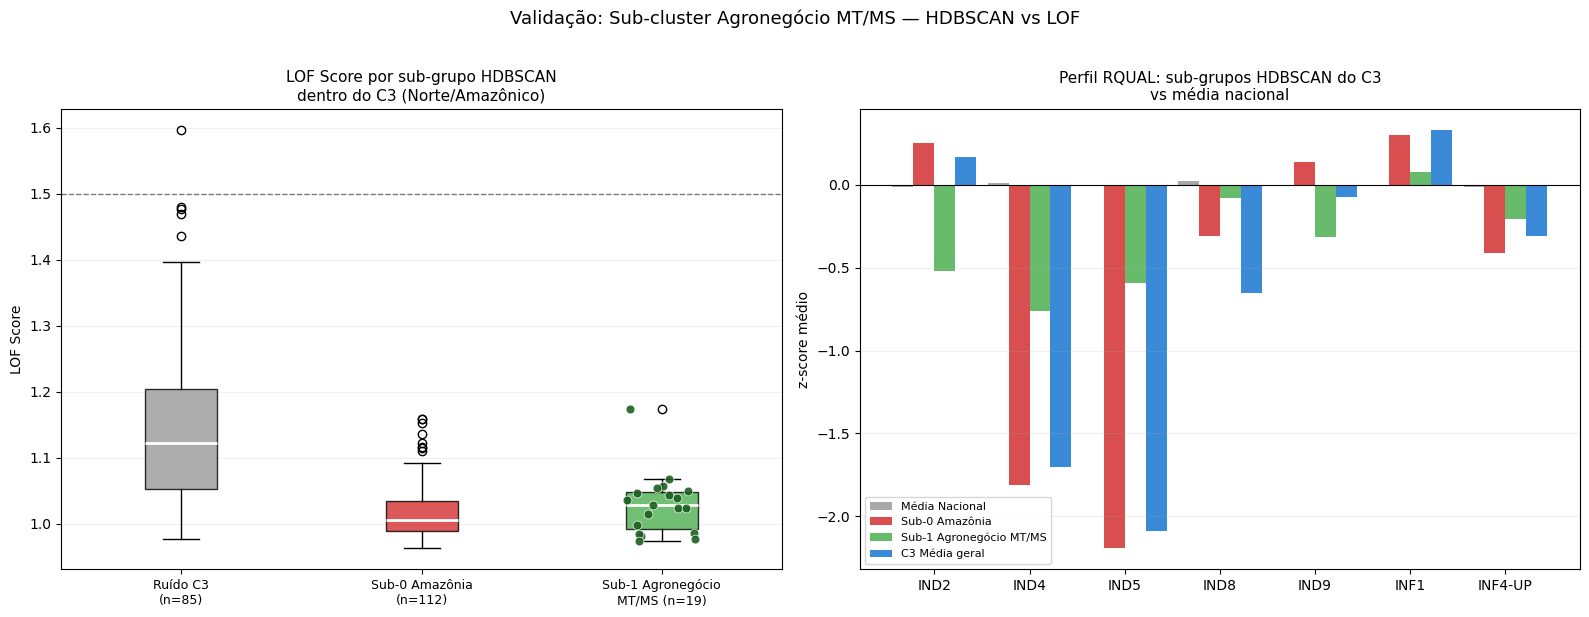

Salvo: fig_c3_agronegocio_hdbscan_vs_lof.png


In [7]:
# Bloco 6 — Visualização: LOF score dentro do C3 por sub-grupo HDBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel 1: LOF score por sub-grupo HDBSCAN dentro do C3
ax = axes[0]
grupos_c3 = {
    'Ruído C3\n(n=85)':              (ruido_c3['lof_score'], '#999999'),
    'Sub-0 Amazônia\n(n=112)':       (amazonia['lof_score'], '#D32F2F'),
    'Sub-1 Agronegócio\nMT/MS (n=19)': (agro['lof_score'],   '#4CAF50'),
}
data_c3 = [v[0] for v in grupos_c3.values()]
labels_c3 = list(grupos_c3.keys())
cores_c3  = [v[1] for v in grupos_c3.values()]

bp = ax.boxplot(data_c3, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, cor in zip(bp['boxes'], cores_c3):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)

# Adicionar pontos individuais do Agronegócio
jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(agro))
ax.scatter(3 + jitter, agro['lof_score'], c='#1B5E20', s=40, alpha=0.9,
           zorder=5, linewidths=0.5, edgecolors='white')

ax.set_xticklabels(labels_c3, fontsize=9)
ax.set_ylabel('LOF Score')
ax.set_title('LOF Score por sub-grupo HDBSCAN\ndentro do C3 (Norte/Amazônico)', fontsize=11)
ax.axhline(1.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(axis='y', alpha=0.2)

# Painel 2: Perfil RQUAL comparativo
ax = axes[1]
x = np.arange(len(IND_COLS))
width = 0.22
cores_perf = ['#999999', '#D32F2F', '#4CAF50', '#1976D2']

grupos_perf = {
    'Média Nacional': df[IND_COLS].mean(),
    'Sub-0 Amazônia': amazonia[IND_COLS].mean(),
    'Sub-1 Agronegócio MT/MS': agro[IND_COLS].mean(),
    'C3 Média geral': c3[IND_COLS].mean(),
}
for i, (label, vals) in enumerate(grupos_perf.items()):
    ax.bar(x + i*width, vals.values, width, label=label, color=cores_perf[i], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(IND_COLS, fontsize=10)
ax.set_ylabel('z-score médio')
ax.set_title('Perfil RQUAL: sub-grupos HDBSCAN do C3\nvs média nacional', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.2)

plt.suptitle('Validação: Sub-cluster Agronegócio MT/MS — HDBSCAN vs LOF', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_c3_agronegocio_hdbscan_vs_lof.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_c3_agronegocio_hdbscan_vs_lof.png')

---
## Seção 4 — O que o LOF encontrou que o HDBSCAN ignorou?

O HDBSCAN classificou C1, C2 e C4 inteiramente como ruído — sem sub-estruturas detectadas.  
O LOF, por operar individualmente, encontrou excepcionais em todos os clusters.  
Aqui investigamos os achados do LOF nesses clusters "invisíveis" ao HDBSCAN.

In [8]:
# Bloco 7 — Achados exclusivos do LOF (C1, C2, C4)
print('Municípios excepcionais (LOF) nos clusters ignorados pelo HDBSCAN:\n')

cols_exib = ['nome_mun_rqual', 'uf_rqual', 'lof_score'] + IND_COLS
cols_exib = [c for c in cols_exib if c in df.columns]

for k in [1, 2, 4]:
    sub = df[(df['kmeans_cluster'] == k) & df['flag_lof']].copy()
    top = sub.nlargest(8, 'lof_score')[cols_exib].reset_index(drop=True)
    for c in ['lof_score'] + IND_COLS:
        if c in top.columns: top[c] = top[c].round(3)
    print(f'─── C{k}: {NOMES_CURTOS[k]} — {len(sub)} excepcionais ───')
    display(top)
    print()

Municípios excepcionais (LOF) nos clusters ignorados pelo HDBSCAN:

─── C1: Intermediário — 306 excepcionais ───


,nome_mun_rqual,uf_rqual,lof_score,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
0,Águas de São Pedro,SP,2.266,-0.437,0.097,0.485,0.220,1.120,-0.923,-0.696
1,Camargo,RS,1.988,-0.937,1.199,1.102,0.174,0.623,1.035,3.100
2,Campo Alegre de Goiás,GO,1.920,4.118,-0.671,-1.440,0.461,-2.602,-0.333,-0.426
3,São Vendelino,RS,1.885,4.275,0.567,0.907,0.249,-3.566,1.892,2.020
4,Tunas,RS,1.880,-0.366,-4.055,-4.312,0.339,-0.005,1.931,-0.614
5,Pedras Altas,RS,1.841,-0.843,1.352,1.099,-0.459,0.305,5.710,-0.637
6,Silvanópolis,TO,1.821,-0.725,-4.055,-0.824,0.528,-4.105,1.621,-0.704
7,Ortigueira,PR,1.802,0.314,0.013,0.584,-1.562,-1.487,-0.013,-0.226



─── C2: Nordeste Periférico — 206 excepcionais ───


,nome_mun_rqual,uf_rqual,lof_score,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
0,São Bento do Norte,RN,2.225,2.059,1.018,-1.992,0.625,0.749,-1.313,-0.250
1,Fernando de Noronha,PE,2.010,1.311,-4.055,-4.336,0.465,-1.235,1.879,-0.688
2,Curionópolis,PA,1.975,-0.213,0.734,-0.137,-4.162,-0.725,1.610,-0.740
3,Parazinho,RN,1.967,-0.571,-0.091,0.411,0.340,0.952,-1.067,-0.029
4,Toritama,PE,1.867,-0.520,0.619,0.625,0.378,0.708,0.453,-0.695
5,Arapiraca,AL,1.839,-0.785,0.434,0.725,0.303,-0.511,-0.363,1.713
6,Teotônio Vilela,AL,1.802,-0.189,0.770,0.110,0.412,-0.714,-0.543,0.470
7,Branquinha,AL,1.797,2.000,-1.117,-1.743,-0.670,-0.993,0.794,-0.664



─── C4: Capitais/Destaques — 3 excepcionais ───


,nome_mun_rqual,uf_rqual,lof_score,IND2,IND4,IND5,IND8,IND9,INF1,INF4-UP
0,Porto Velho,RO,1.285,-0.792,0.170,-0.203,0.346,0.576,-0.818,1.252
1,Brasília,DF,1.178,-0.696,0.126,0.444,0.345,0.277,-0.618,1.312
2,Rio Branco,AC,1.090,-0.700,0.282,-0.132,0.522,0.553,-0.719,2.195


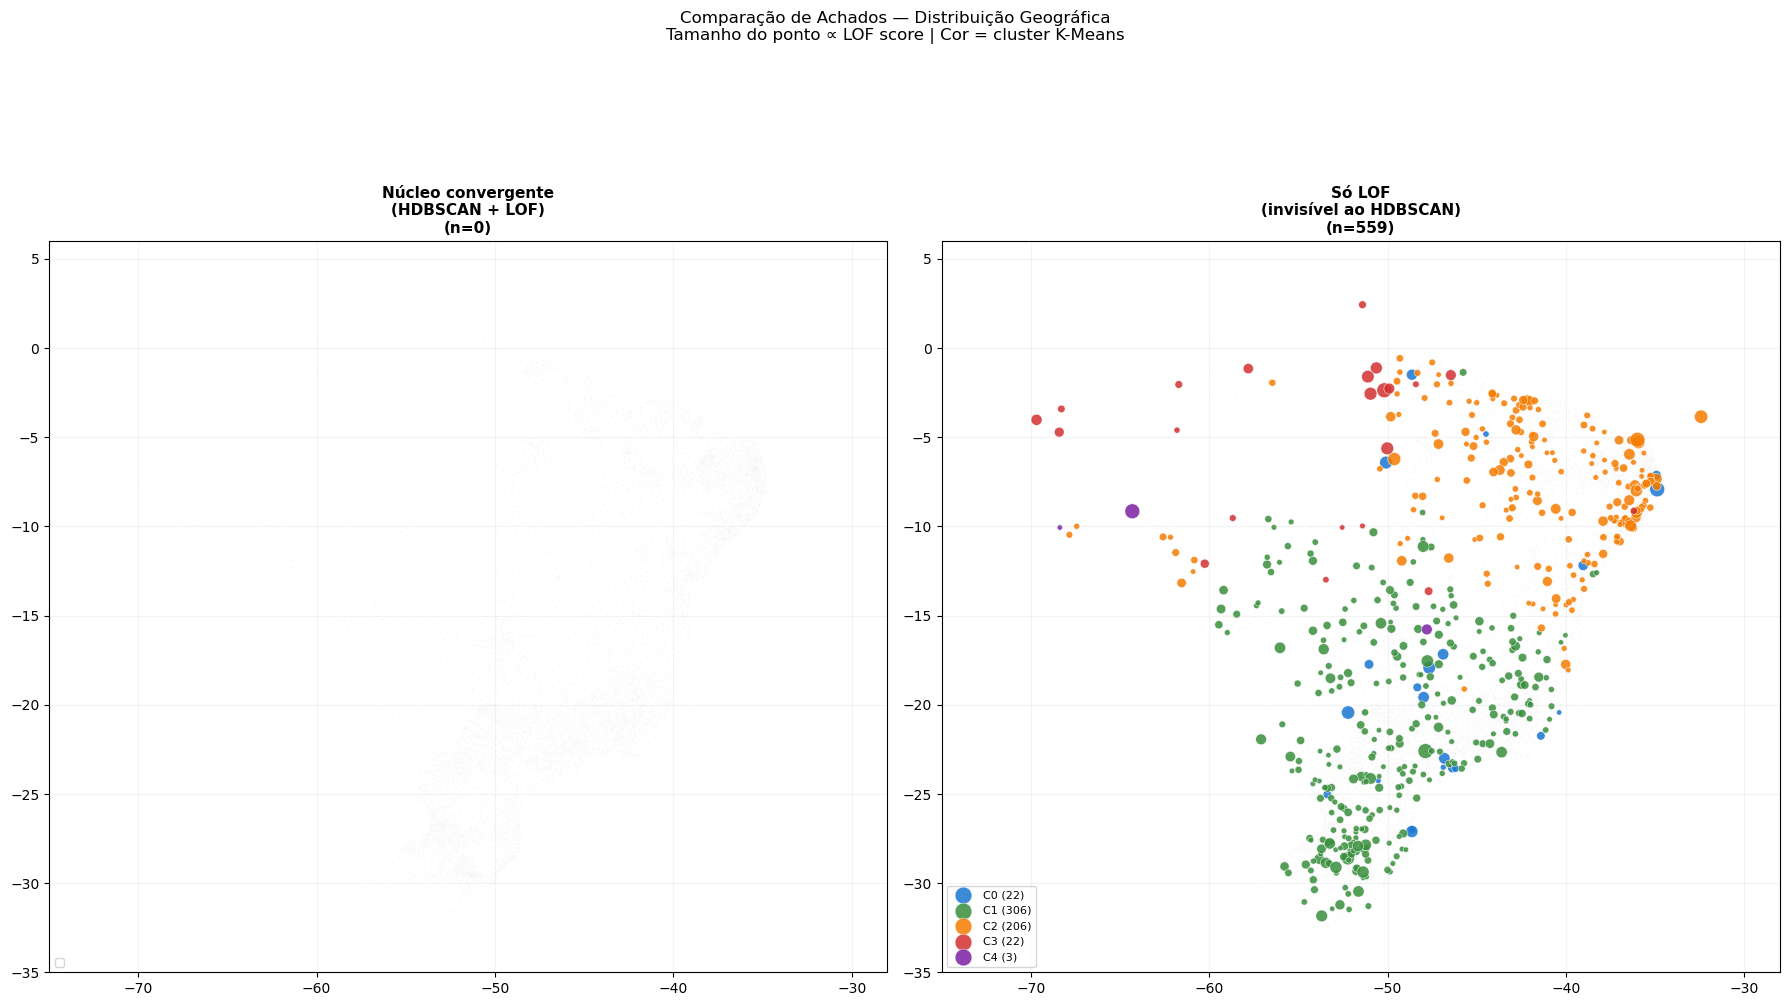

Salvo: fig_mapa_comparacao_achados.png


In [9]:
# Bloco 8 — Mapa: só LOF (excepcionais novos) vs núcleo convergente
try:
    from geobr import read_municipality
    gdf = read_municipality(code_muni='all', year=2020)
    gdf_proj = gdf.to_crs('EPSG:5880')
    gdf['lat_geo'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').y
    gdf['lon_geo'] = gdf_proj.geometry.centroid.to_crs('EPSG:4326').x
    gdf = gdf.rename(columns={'code_muni': 'cod_mun'})[['cod_mun', 'lat_geo', 'lon_geo']]
    gdf['cod_mun'] = gdf['cod_mun'].astype(int)
    df_map = df.merge(gdf, on='cod_mun', how='left')
    usar_geo = df_map[['lat_geo', 'lon_geo']].notna().all(axis=1).mean() > 0.9
except Exception:
    usar_geo = False

if not usar_geo:
    df_map = df.copy()
    df_map['lat_geo'] = df['umap_y']
    df_map['lon_geo'] = df['umap_x']

lat_col, lon_col = 'lat_geo', 'lon_geo'

fig, axes = plt.subplots(1, 2, figsize=(18, 11 if usar_geo else 8))

for ax, (cat, cor, titulo) in zip(axes, [
    ('Núcleo convergente', '#B71C1C', 'Núcleo convergente\n(HDBSCAN + LOF)'),
    ('Só LOF',             '#E65100', 'Só LOF\n(invisível ao HDBSCAN)'),
]):
    # Fundo: todos os normais
    fundo = df_map[df_map['categoria'] == 'Consenso normal']
    ax.scatter(fundo[lon_col], fundo[lat_col], c='#EEEEEE', s=2, alpha=0.3, linewidths=0)

    # Destaque por cluster
    destaque = df_map[df_map['categoria'] == cat].copy()
    for k, cor_k in enumerate(CORES_CLUSTERS):
        sub = destaque[destaque['kmeans_cluster'] == k]
        if len(sub) > 0:
            # Tamanho proporcional ao LOF score
            s_norm = (sub['lof_score'] - sub['lof_score'].min()) / \
                     (sub['lof_score'].max() - sub['lof_score'].min() + 1e-9)
            sizes  = 15 + s_norm * 100
            ax.scatter(sub[lon_col], sub[lat_col],
                       c=cor_k, s=sizes, alpha=0.85,
                       linewidths=0.4, edgecolors='white',
                       label=f'C{k} ({len(sub)})')

    if usar_geo:
        ax.set_xlim(-75, -28); ax.set_ylim(-35, 6)
        ax.set_aspect('equal')
    ax.set_title(titulo + f'\n(n={len(destaque)})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, markerscale=1.5, loc='lower left')
    ax.grid(alpha=0.15)

titulo_eixo = 'Distribuição Geográfica' if usar_geo else 'Espaço UMAP 2D'
plt.suptitle(f'Comparação de Achados — {titulo_eixo}\n'
             'Tamanho do ponto ∝ LOF score | Cor = cluster K-Means',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_mapa_comparacao_achados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_mapa_comparacao_achados.png')

---
## Seção 5 — Síntese comparativa e conclusões

In [10]:
# Bloco 9 — Síntese quantitativa final
n_hdb   = df['flag_hdbscan'].sum()
n_lof   = df['flag_lof'].sum()
n_ambos = (df['flag_hdbscan'] & df['flag_lof']).sum()
n_uniao = (df['flag_hdbscan'] | df['flag_lof']).sum()

# Score LOF dos grupos
lof_hdb_mediana  = df.loc[df['flag_hdbscan'], 'lof_score'].median()
lof_rest_mediana = df.loc[~df['flag_hdbscan'], 'lof_score'].median()

# Percentual de HDBSCAN confirmado pelo LOF
pct_hdb_confirmado = 100 * n_ambos / n_hdb if n_hdb > 0 else 0

print('=' * 65)
print('SÍNTESE COMPARATIVA FINAL')
print('=' * 65)
print(f'  HDBSCAN identificou       : {n_hdb:,} municípios ({100*n_hdb/len(df):.1f}%)')
print(f'  LOF identificou           : {n_lof:,} municípios ({100*n_lof/len(df):.1f}%)')
print(f'  Sobreposição (ambos)      : {n_ambos:,} municípios ({100*n_ambos/len(df):.1f}%)')
print(f'  União (qualquer um)       : {n_uniao:,} municípios ({100*n_uniao/len(df):.1f}%)')
print()
print(f'  % do HDBSCAN confirmado pelo LOF  : {pct_hdb_confirmado:.1f}%')
print(f'  LOF score mediana — HDBSCAN       : {lof_hdb_mediana:.3f}')
print(f'  LOF score mediana — demais        : {lof_rest_mediana:.3f}')
print()
print('Cobertura por cluster:')
cob = df.groupby('kmeans_cluster').agg(
    n_total    = ('cod_mun', 'count'),
    n_hdbscan  = ('flag_hdbscan', 'sum'),
    n_lof      = ('flag_lof', 'sum'),
    n_ambos    = (pd.Series.name if False else 'categoria', lambda x: (x == 'Núcleo convergente').sum()),
    lof_median = ('lof_score', 'median'),
).rename(index=NOMES_CURTOS)
cob['pct_hdb'] = (100 * cob['n_hdbscan'] / cob['n_total']).round(1)
cob['pct_lof'] = (100 * cob['n_lof']     / cob['n_total']).round(1)
display(cob[['n_total','n_hdbscan','pct_hdb','n_lof','pct_lof','n_ambos','lof_median']].round(3))

SÍNTESE COMPARATIVA FINAL
  HDBSCAN identificou       : 204 municípios (3.7%)
  LOF identificou           : 559 municípios (10.0%)
  Sobreposição (ambos)      : 0 municípios (0.0%)
  União (qualquer um)       : 763 municípios (13.7%)

  % do HDBSCAN confirmado pelo LOF  : 0.0%
  LOF score mediana — HDBSCAN       : 1.005
  LOF score mediana — demais        : 1.082

Cobertura por cluster:


,n_total,n_hdbscan,pct_hdb,n_lof,pct_lof,n_ambos,lof_median
kmeans_cluster,,,,,,,
Urbano-Avançado,216,73,33.8,22,10.2,0,1.051
Intermediário,3054,0,0.0,306,10.0,0,1.094
Nordeste Periférico,2057,0,0.0,206,10.0,0,1.065
Norte/Amazônico,216,131,60.6,22,10.2,0,1.032
Capitais/Destaques,27,0,0.0,3,11.1,0,0.998


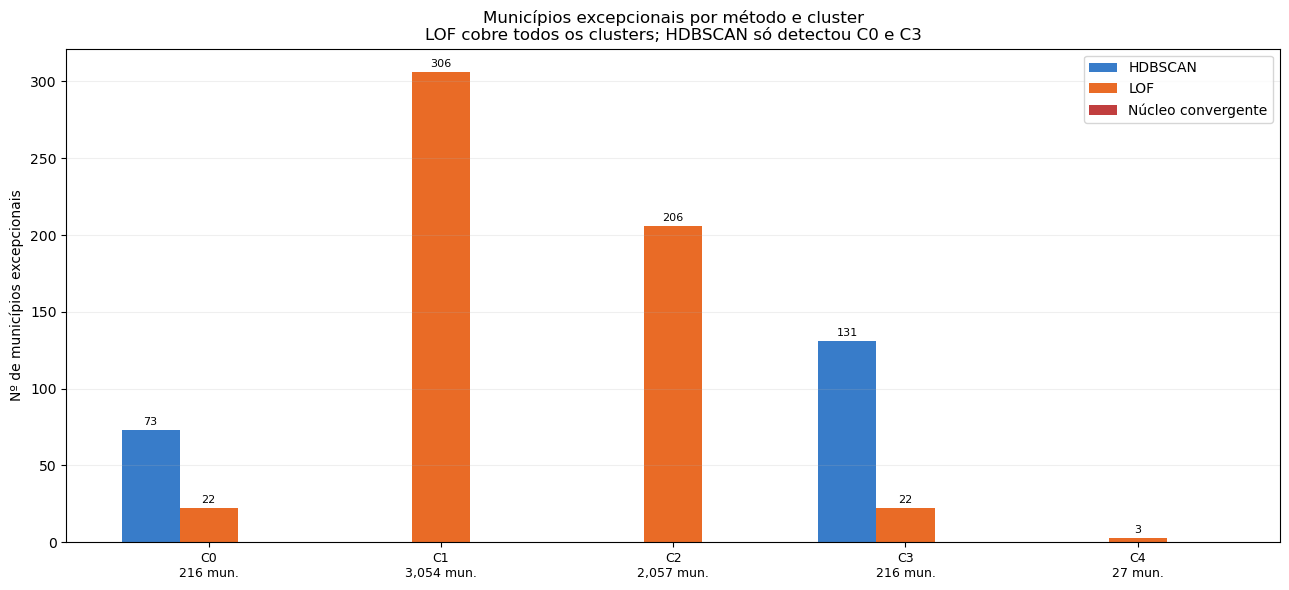

Salvo: fig_cobertura_por_cluster.png


In [11]:
# Bloco 10 — Gráfico final: cobertura por cluster
clusters   = list(NOMES_CURTOS.values())
n_totais   = [df[df['kmeans_cluster'] == k].shape[0]                    for k in range(5)]
n_hdb_por  = [df[(df['kmeans_cluster'] == k) & df['flag_hdbscan']].shape[0] for k in range(5)]
n_lof_por  = [df[(df['kmeans_cluster'] == k) & df['flag_lof']].shape[0]     for k in range(5)]
n_ambos_por = [df[(df['kmeans_cluster'] == k) & df['flag_hdbscan'] & df['flag_lof']].shape[0] for k in range(5)]

x = np.arange(len(clusters))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, n_hdb_por,   width, label='HDBSCAN',            color='#1565C0', alpha=0.85)
b2 = ax.bar(x,         n_lof_por,   width, label='LOF',                color='#E65100', alpha=0.85)
b3 = ax.bar(x + width, n_ambos_por, width, label='Núcleo convergente', color='#B71C1C', alpha=0.85)

# Rótulos
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 2, str(int(h)),
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'C{k}\n{n:,} mun.' for k, n in enumerate(n_totais)],
    fontsize=9
)
ax.set_ylabel('Nº de municípios excepcionais')
ax.set_title('Municípios excepcionais por método e cluster\n'
             'LOF cobre todos os clusters; HDBSCAN só detectou C0 e C3', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('fig_cobertura_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: fig_cobertura_por_cluster.png')

---
## Seção 6 — Conclusões

### Achado central: HDBSCAN e LOF encontram tipos OPOSTOS de excepcionalidade

> **Sobreposição: 0 municípios** — nenhum município identificado pelo HDBSCAN aparece entre os excepcionais do LOF.  
> Isso não é falha metodológica — é o comportamento esperado quando se entende o que cada método mede.

| Dimensão | HDBSCAN (sub-clusters) | LOF (outliers) |
|---|---|---|
| **O que detecta** | Municípios que são **similares entre si** e formam um grupo denso dentro do cluster | Municípios **isolados**, sem vizinhança densa ao redor |
| **Tipo de excepcionalidade** | Excepcionalidade por **coesão de grupo** | Excepcionalidade por **isolamento individual** |
| **Por que não se sobrepõem** | Membro de grupo denso → vizinhos próximos → LOF score baixo | Ponto isolado → sem grupo ao redor → não forma sub-cluster HDBSCAN |
| **Cobertura** | Apenas C0 e C3 | Todos os 5 clusters |
| **Saída** | Label de grupo | Score contínuo |

### 1. Sub-cluster Agronegócio MT/MS (C3-Sub-3001): LOF score BAIXO — e isso confirma o achado

Os 19 municípios do agronegócio mato-grossense têm **LOF score abaixo de 1.2** — aparentemente "normais" para o LOF.  
Isso ocorre porque os 19 municípios são **similares entre si**: cada um tem 18 vizinhos com perfil parecido, formando um grupo coeso.  
O LOF não os sinaliza justamente porque **não estão isolados** — estão juntos.  
O HDBSCAN é o método certo para detectar esse tipo de padrão: um sub-grupo territorialmente coeso que desvia do cluster pai.

> **Conclusão:** O sub-grupo Agronegócio MT/MS é uma **exceção de grupo** (HDBSCAN), não uma exceção individual (LOF).  
> Ambas as interpretações são válidas — mas para usos diferentes.

### 2. O LOF expande a análise para C1 e C2 (54% + 37% dos municípios)

Com o HDBSCAN, os 5.111 municípios de C1 e C2 eram analiticamente opacos.  
O LOF identificou **512 excepcionais** nesse universo com perfis atípicos em combinações de indicadores.  
São casos invisíveis ao HDBSCAN — anomalias individuais sem grupo coeso ao redor.

### 3. Os 763 municípios da união são diferentes em natureza

| Categoria | N | Interpretação regulatória |
|---|---:|---|
| **Só HDBSCAN** (204) | 3.7% | Fazem parte de um sub-grupo coeso distinto — ação por território/grupo |
| **Só LOF** (559) | 10.0% | Anomalias individuais — ação caso a caso |
| **Núcleo convergente** | 0 | — (os métodos medem dimensões ortogonais) |

### 4. Recomendação de uso integrado

```
Para análise de sub-grupos territoriais → HDBSCAN
  Exemplos: Agronegócio MT/MS, Amazônia profunda, metrópoles com gargalo

Para ranking de municípios excepcionais → LOF
  Exemplos: municípios com combinação atípica de IND5 alto + IND4 baixo

Para cobertura máxima → usar os 763 da união (HDBSCAN ∪ LOF)
```

In [12]:
# Bloco E — Exportação
cols_export = (
    ['cod_mun', 'nome_mun_rqual', 'uf_rqual', 'kmeans_cluster',
     'flag_hdbscan', 'hdbscan_cluster', 'flag_lof', 'lof_score', 'categoria']
    + IND_COLS + SOC_COLS
)
cols_export = [c for c in cols_export if c in df.columns]

# Exportar todos os excepcionais (HDBSCAN ou LOF)
df_exc = (
    df[df['categoria'] != 'Consenso normal']
    .copy()
    .sort_values(['kmeans_cluster', 'categoria', 'lof_score'], ascending=[True, True, False])
)[cols_export]

arq_comp = 'comparacao_achados_hdbscan_lof.csv'
df_exc.to_csv(arq_comp, index=False)
print(f'Salvo: {arq_comp} | {len(df_exc)} municípios excepcionais (HDBSCAN ∪ LOF)')
print()
print('Distribuição por categoria:')
display(
    df_exc.groupby('categoria')
    .agg(n=('cod_mun', 'count'),
         lof_mediana=('lof_score', 'median'),
         lof_max=('lof_score', 'max'))
    .round(3)
)

Salvo: comparacao_achados_hdbscan_lof.csv | 763 municípios excepcionais (HDBSCAN ∪ LOF)

Distribuição por categoria:


,n,lof_mediana,lof_max
categoria,,,
Só HDBSCAN,204,1.005,1.186
Só LOF,559,1.363,2.266
